# 3 — Distance and neighbourhood entropy based on cell typing

Data: **PathoCell** (`cohort.fetch_pathocell`, ~350 MB per region) — see [Tutorial 0](./00_data.ipynb).

Notebook 2 turned a virtual stain into cell labels. This one asks what those labels
are good for, with two readouts that need nothing but a label and a position per cell:

* **Cell-to-cell distance** — how far a T cell sits from the nearest vessel. The step where a
  lymphocyte leaves the circulation and enters tissue, on `reg032_B`.
* **Neighbourhood entropy** — how mixed a cell's ten nearest neighbours are, in bits. Low is a
  homogeneous pocket, high is an interface where lineages meet, on `reg033_B`.

For how to generate a training-based cell typing, check [Tutorial 2](./02_cell_typing.ipynb).

In [1]:
import _common
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from scipy.stats import spearmanr

from quest import QuestGenerator
from questkit import cells, celltyping, cohort, plotting
from questkit.fit_typer import region_table
from questkit.predict_mif import predict_region

MPP, K_NN = 0.3775, 10                      # the cohort's own pitch; neighbours per cell
DIST_REGION, ENT_REGION = "reg032_B", "reg033_B"
ARMS = ["quest-semantic", "quest-id", "quest-eva"]
# one colour per arm, used by every panel below
COL = {"published": "#202427", "real": "#5B6BB0", "quest-semantic": "#d62728",
       "quest-id": "#9467bd", "quest-eva": "#2ca02c"}
# how each arm is named in a figure; the registry keys are lowercase, the models are not
DISP = {"published": "published", "real": "real MIF",
        "quest-semantic": "QUEST-semantic", "quest-id": "QUEST-ID",
        "quest-eva": "QUEST-Eva"}
cohort.fetch_pathocell([DIST_REGION, ENT_REGION])     # ~350 MB each, no-op once present

typer = celltyping.load_typers(
    f"{_common.QUEST_CODE}/checkpoints/celltyper_quest-semantic.npz")["real"]
held = typer["holdout"].split(",")
for r in (DIST_REGION, ENT_REGION):
    assert r in held, f"{r} is not held out of the typer fit; it would be training data"
print(f"typer: {typer['n_train']:,} cells, {len(typer['classes'])} classes "
      f"({typer['scheme']}), fitted on the REAL MIF arm")
print(f"held out: {', '.join(held)}")

[pathocell] all 2 regions already in data/PathoCell
typer: 210,002 cells, 14 classes (coarse15), fitted on the REAL MIF arm
held out: reg016_B, reg032_B, reg033_B


In [2]:
# Cell types for real MIF and virtual models
def type_region(name):
    _he, inst, ids, real, gt = cohort.load_pathocell_typing(name)
    x, y = cells.centroids(inst)
    M, _ = cells.cell_means(real, inst)
    M = np.stack([cells.scale_p99(M[:, i]) for i in range(M.shape[1])], 1)
    out = {"real": celltyping.apply_typer(typer, M, cohort.pathocell_panel())}
    for m in ARMS:
        tab = region_table(name, model=m)          # cached per-cell means of that model
        out[m] = celltyping.apply_typer(typer, tab["virt"], cohort.pathocell_panel(m))
    return x, y, np.array([t if t else "" for t in gt]), {k: np.asarray(v, str)
                                                          for k, v in out.items()}


dx, dy, d_gt, d_arms = type_region(DIST_REGION)
ex, ey, e_gt, e_arms = type_region(ENT_REGION)
print(f"{DIST_REGION}: {len(dx)} cells   {ENT_REGION}: {len(ex)} cells")
print("arms:", ["published"] + list(d_arms))

reg032_B: 1616 cells   reg033_B: 3466 cells
arms: ['published', 'real', 'quest-semantic', 'quest-id', 'quest-eva']


## Distance: T cell to nearest vessel

In [3]:
A, B = ["T cells"], ["Vasculature/Lymphatics"]
MIN_CELLS = 15


# distance from every A cell to its nearest B cell, in um; None if either class is too rare
def nn_distance(lab, x, y):
    a, b = np.isin(lab, A), np.isin(lab, B)
    if a.sum() < MIN_CELLS or b.sum() < MIN_CELLS:
        return None
    return cKDTree(np.c_[x[b], y[b]]).query(np.c_[x[a], y[a]])[0] * MPP


dist = {"published": nn_distance(d_gt, dx, dy)}
dist.update({k: nn_distance(v, dx, dy) for k, v in d_arms.items()})
for k, v in dist.items():
    n_a = int(np.isin(d_gt if k == "published" else d_arms[k], A).sum())
    print(f"  {k:15s} {n_a:4d} T cells   median {np.median(v):5.1f} um")

  published        362 T cells   median  47.7 um
  real             342 T cells   median  46.6 um
  quest-semantic   162 T cells   median  34.2 um
  quest-id         114 T cells   median  40.9 um
  quest-eva        345 T cells   median  53.7 um


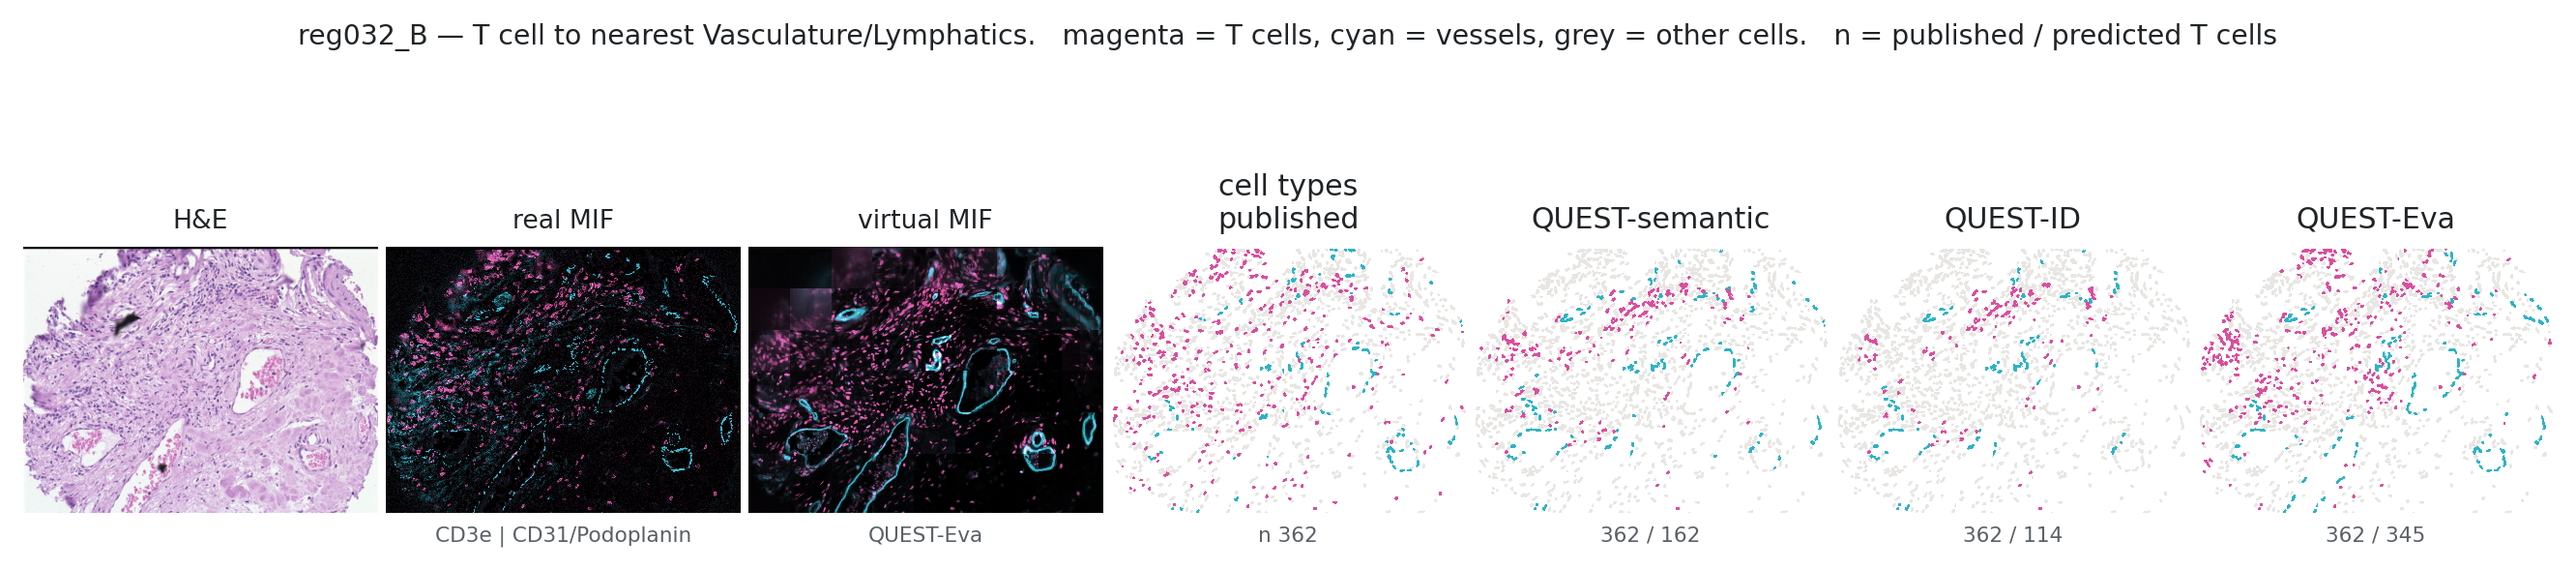

In [4]:
# --- the distance case: H&E, the marker pair on both arms, and the cell maps
C_A, C_B, C_BG = "#d94f9e", "#2fb3c4", "#e8e6e3"        # T cells / vessels / everything else
PAIR_PAL = {"T cells": C_A, "Vasculature/Lymphatics": C_B}
M_A, M_B = ["CD3e"], ["CD31", "Podoplanin"]             # channels the two classes are read from
MIF_ARM = "quest-eva"                                   # whose prediction the MIF panel shows

_he, d_inst, d_ids, d_real, _ = cohort.load_pathocell_typing(DIST_REGION)
gen = QuestGenerator(MIF_ARM, device=_common.DEVICE)
d_virt = predict_region(gen, _he, cohort.pathocell_panel(MIF_ARM))
del gen

panel = cohort.pathocell_panel(MIF_ARM)
def chan(stack, names):
    return np.max(np.stack([stack[panel.index(m)] for m in names if m in panel]), 0)

maps = [("published", d_gt)] + [(m, d_arms[m]) for m in ARMS]
fig, axes = plt.subplots(1, 3 + len(maps), figsize=(1.6 * (3 + len(maps)), 2.6))

axes[0].imshow(_he); plotting.bare(axes[0])
axes[0].set_title("H&E", fontsize=8, color=plotting.INK)
for ax, src, ttl in ((axes[1], d_real, "real MIF"), (axes[2], d_virt, "virtual MIF")):
    plotting.two_colour_markers(ax, chan(src, M_A), chan(src, M_B), title=ttl)
axes[1].set_xlabel("CD3e | CD31/Podoplanin", fontsize=6.5, color=plotting.MUTED)
axes[2].set_xlabel(DISP[MIF_ARM], fontsize=6.5, color=plotting.MUTED)

for ax, (lab, ty) in zip(axes[3:], maps):
    plotting.paint_types(ax, d_inst, d_ids, ty, palette=PAIR_PAL, unlabelled=C_BG,
                         title="cell types\npublished" if lab == "published" else DISP[lab])
    n_a = int(np.isin(ty, A).sum())
    ax.set_xlabel(f"n {n_a}" if lab == "published"
                  else f"{int(np.isin(d_gt, A).sum())} / {n_a}",
                  fontsize=6.5, color=plotting.MUTED)

fig.suptitle(f"{DIST_REGION} — T cell to nearest Vasculature/Lymphatics.   "
             f"magenta = T cells, cyan = vessels, grey = other cells.   "
             f"n = published / predicted T cells", fontsize=8.5, color=plotting.INK, y=1.04)
fig.tight_layout(w_pad=0.25)
plt.show()

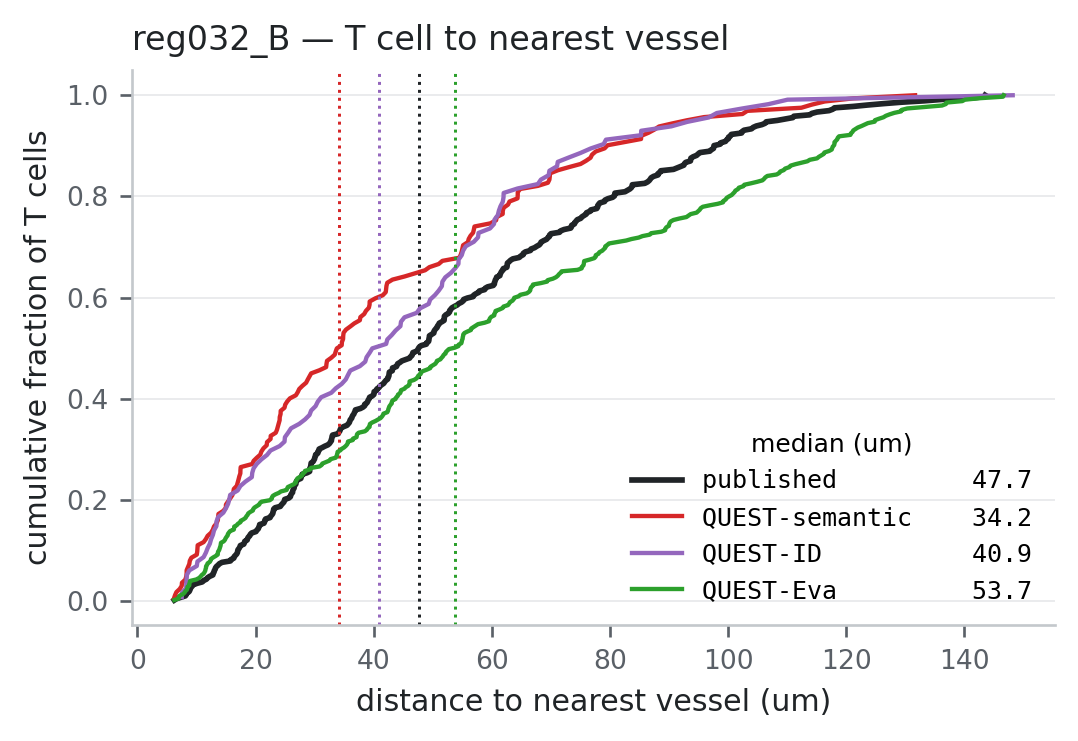

In [5]:
# --- the same distances as a CDF
fig, ax = plt.subplots(figsize=(4.6, 3.2))
for k in ["published"] + ARMS:
    v = np.sort(dist[k])
    ax.plot(v, np.arange(1, len(v) + 1) / len(v), lw=1.7 if k == "published" else 1.3,
            color=COL[k], label=f"{DISP.get(k, k):16s} {np.median(v):5.1f}")
    ax.axvline(np.median(v), ls=":", lw=0.9, color=COL[k])
ax.legend(fontsize=7.5, frameon=False, loc="lower right", title="median (um)",
          title_fontsize=7.5, prop={"family": "monospace", "size": 7.5})
plotting.style(ax, xlabel="distance to nearest vessel (um)",
               ylabel="cumulative fraction of T cells",
               title=f"{DIST_REGION} — T cell to nearest vessel")
fig.tight_layout()
plt.show()

## Entropy: is the neighbourhood mixed or homogeneous?

For every cell, take its ten nearest neighbours in the same region, build the histogram of their
classes and take its Shannon entropy in bits. 

In [6]:
CLASSES = cohort.COARSE15
VMAX = float(np.log2(K_NN))


# Shannon entropy, in bits, of the K_NN-neighbour class histogram around every cell
def entropy(lab, x, y):
    idx = cKDTree(np.c_[x, y]).query(np.c_[x, y], k=K_NN + 1)[1][:, 1:]     # self excluded
    code = np.array([CLASSES.index(v) if v in CLASSES else -1 for v in lab])
    hist = np.stack([(code[idx] == c).sum(1) for c in range(len(CLASSES))], 1) / K_NN
    return -np.sum(np.where(hist > 0, hist * np.log2(np.where(hist > 0, hist, 1)), 0), 1)


E = {"published": entropy(e_gt, ex, ey)}
E.update({k: entropy(v, ex, ey) for k, v in e_arms.items()})
rho = {k: spearmanr(E["published"], v).statistic for k, v in E.items() if k != "published"}
print(f"ceiling log2({K_NN}) = {VMAX:.2f} bits")
for k, v in E.items():
    tag = "" if k == "published" else f"   rho vs published {rho[k]:+.3f}"
    print(f"  {k:15s} mean {v.mean():.3f} bits{tag}")

ceiling log2(10) = 3.32 bits
  published       mean 1.129 bits
  real            mean 1.292 bits   rho vs published +0.857
  quest-semantic  mean 0.939 bits   rho vs published +0.719
  quest-id        mean 1.008 bits   rho vs published +0.651
  quest-eva       mean 0.927 bits   rho vs published +0.510


/tmp/ipykernel_3157674/1302189745.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(w_pad=0.25)


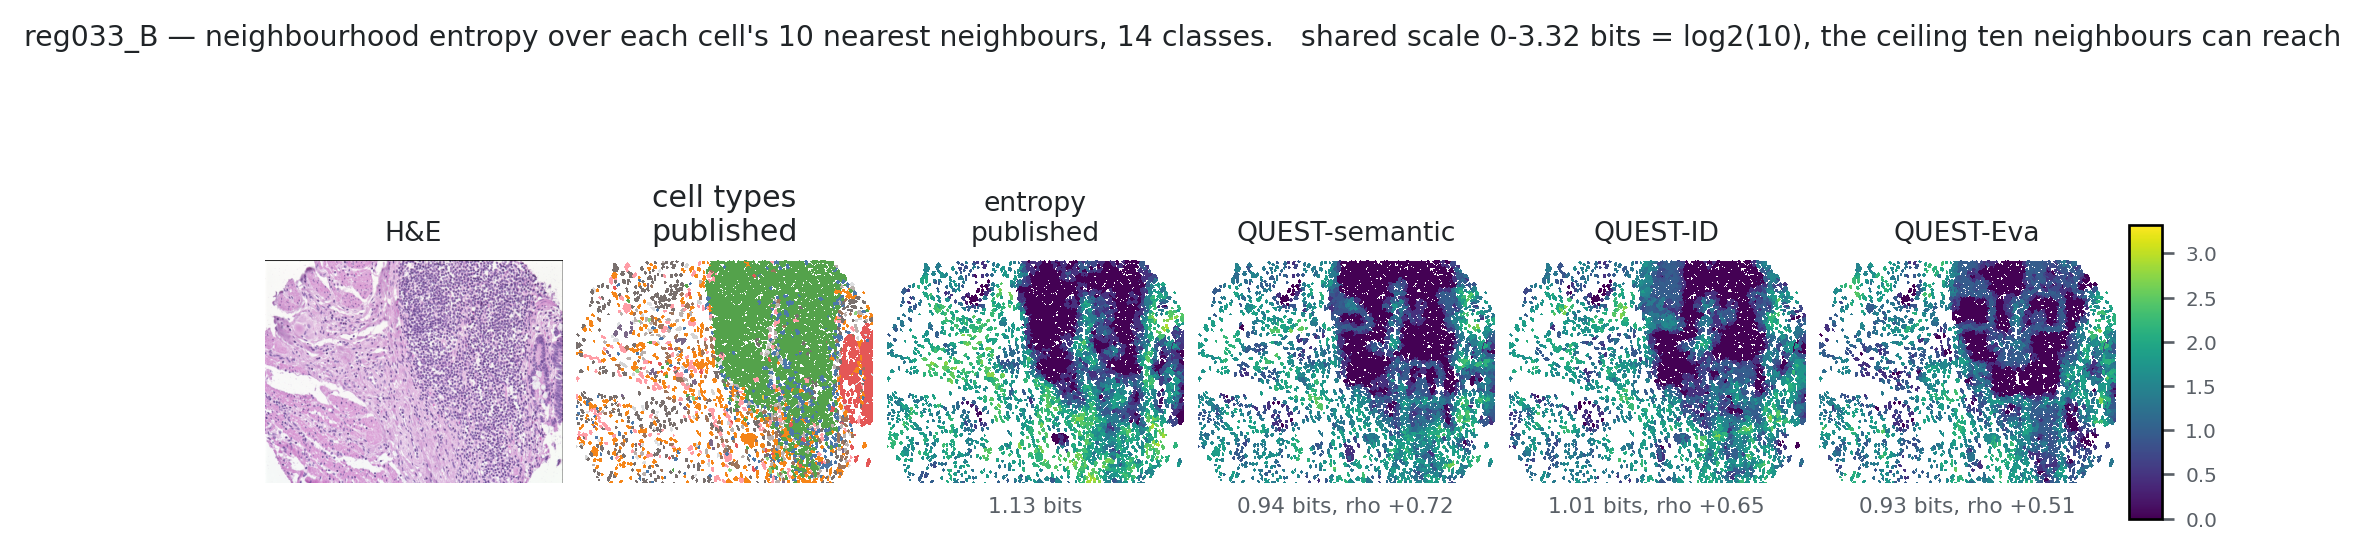

In [7]:
_ehe, e_inst, e_ids, _, _ = cohort.load_pathocell_typing(ENT_REGION)

fig = plt.figure(figsize=(1.6 * 6 + 0.6, 2.7))
gs = fig.add_gridspec(1, 7, wspace=0.05, width_ratios=[1, 1, 1, 1, 1, 1, 0.11])

ax = fig.add_subplot(gs[0, 0]); ax.imshow(_ehe); plotting.bare(ax)
ax.set_title("H&E", fontsize=8, color=plotting.INK)
plotting.paint_types(fig.add_subplot(gs[0, 1]), e_inst, e_ids, e_gt,
                     title="cell types\npublished")
for j, k in enumerate(["published"] + ARMS):
    ax = fig.add_subplot(gs[0, 2 + j])
    sm = plotting.paint_values(ax, e_inst, e_ids, E[k], vmin=0, vmax=VMAX, cmap="viridis",
                               title="entropy\npublished" if k == "published" else DISP[k])
    ax.set_xlabel(f"{E[k].mean():.2f} bits" if k == "published"
                  else f"{E[k].mean():.2f} bits, rho {rho[k]:+.2f}",
                  fontsize=6.5, color=plotting.MUTED)

cax = gs[0, 6].subgridspec(3, 1, height_ratios=[1, 3, 1], hspace=0)
cb = fig.colorbar(sm, cax=fig.add_subplot(cax[1, 0]))
cb.ax.tick_params(labelsize=6, colors=plotting.MUTED)
fig.suptitle(f"{ENT_REGION} — neighbourhood entropy over each cell's {K_NN} nearest neighbours, "
             f"{len(CLASSES)} classes.   shared scale 0-{VMAX:.2f} bits "
             f"= log2({K_NN}), the ceiling ten neighbours can reach",
             fontsize=8.5, color=plotting.INK, y=1.04)
fig.tight_layout(w_pad=0.25)
plt.show()

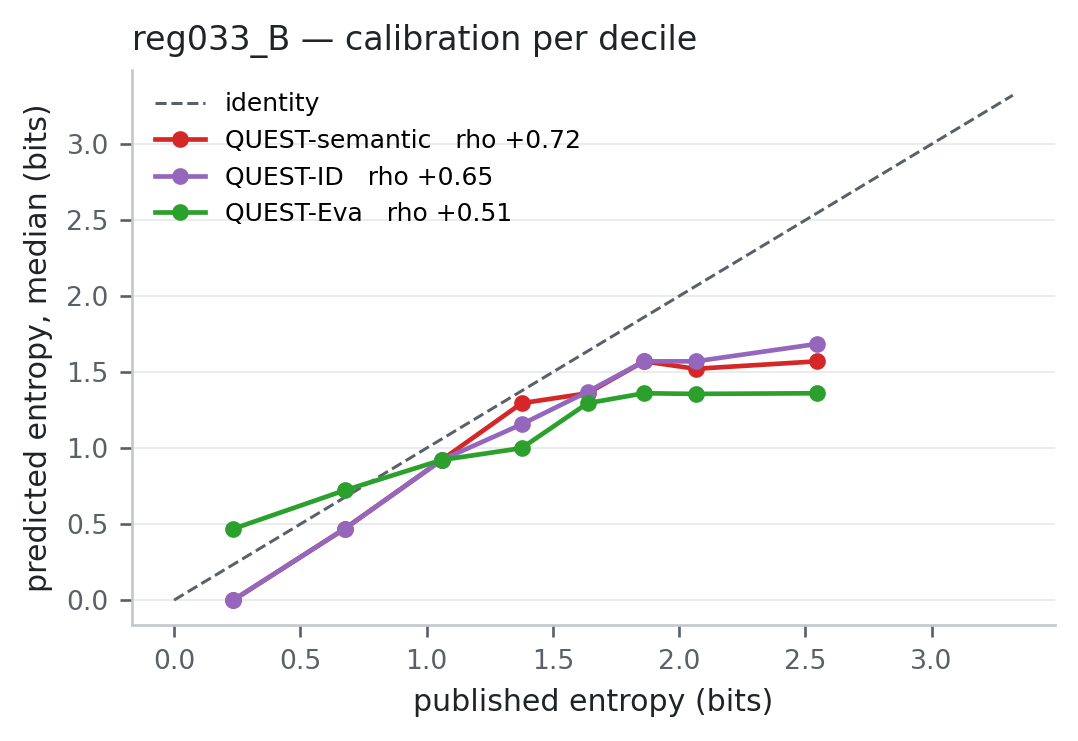

In [8]:
fig, ax = plt.subplots(figsize=(4.6, 3.2))
q = np.quantile(E["published"], np.linspace(0, 1, 11))
mid = 0.5 * (q[:-1] + q[1:])
ax.plot([0, VMAX], [0, VMAX], ls="--", lw=0.9, color="#5A6067", label="identity")
for k in ARMS:
    med = [np.median(E[k][(E["published"] >= a) & (E["published"] < b)]) if
           ((E["published"] >= a) & (E["published"] < b)).any() else np.nan
           for a, b in zip(q[:-1], q[1:])]
    ax.plot(mid, med, "-o", ms=4, lw=1.4, color=COL[k],
            label=f"{DISP[k]}   rho {rho[k]:+.2f}")
ax.legend(fontsize=7.5, frameon=False, loc="upper left")
plotting.style(ax, xlabel="published entropy (bits)", ylabel="predicted entropy, median (bits)",
               title=f"{ENT_REGION} — calibration per decile")
fig.tight_layout()
plt.show()